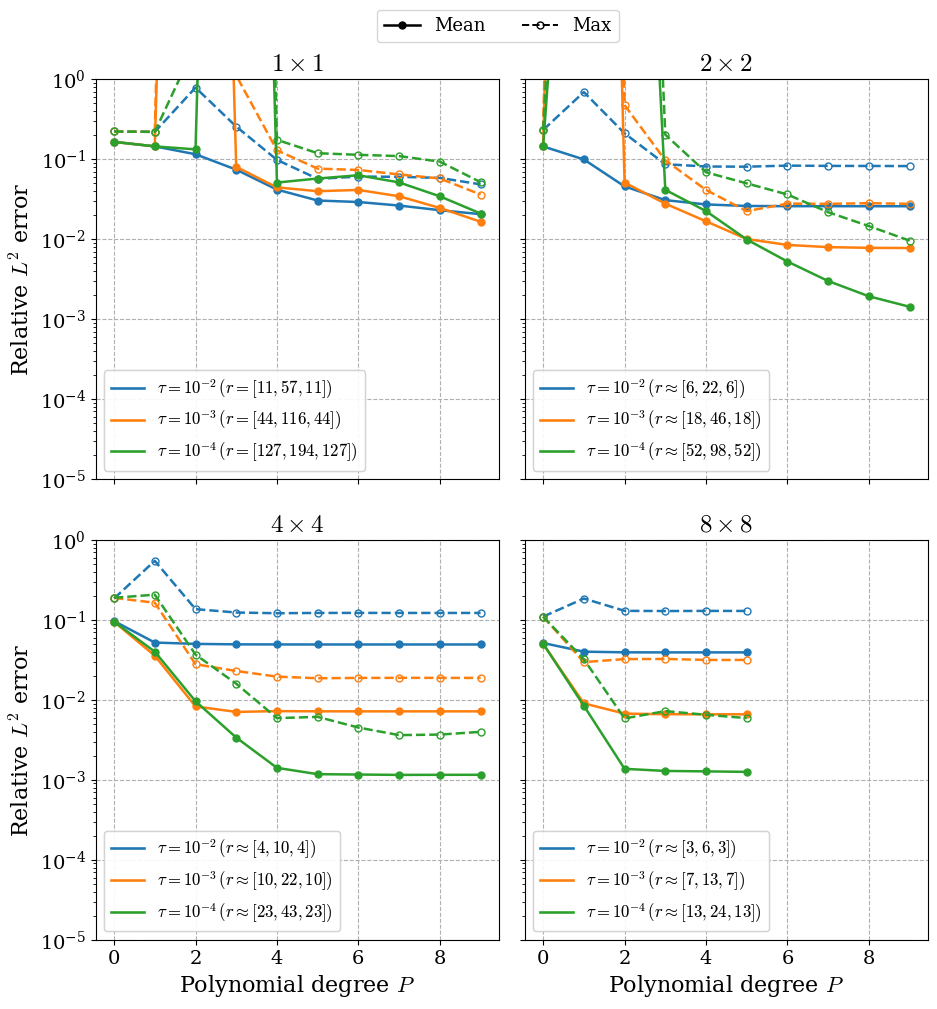

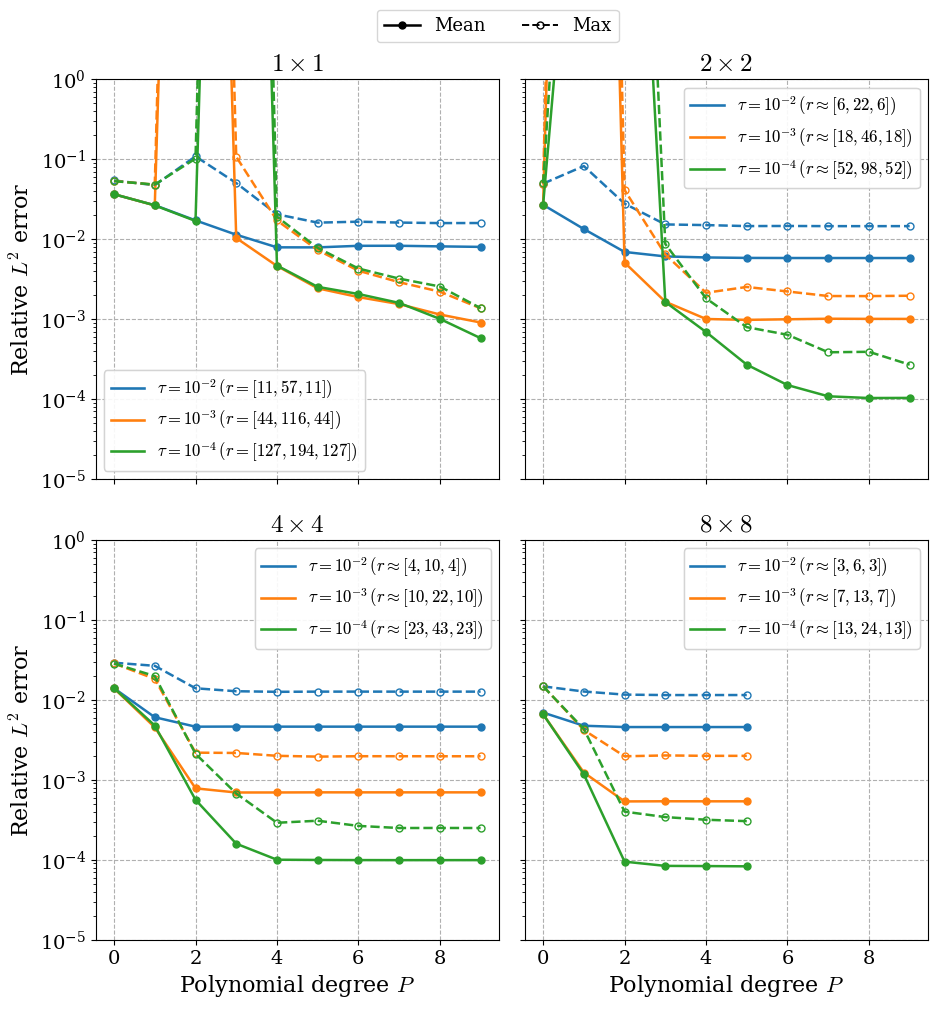

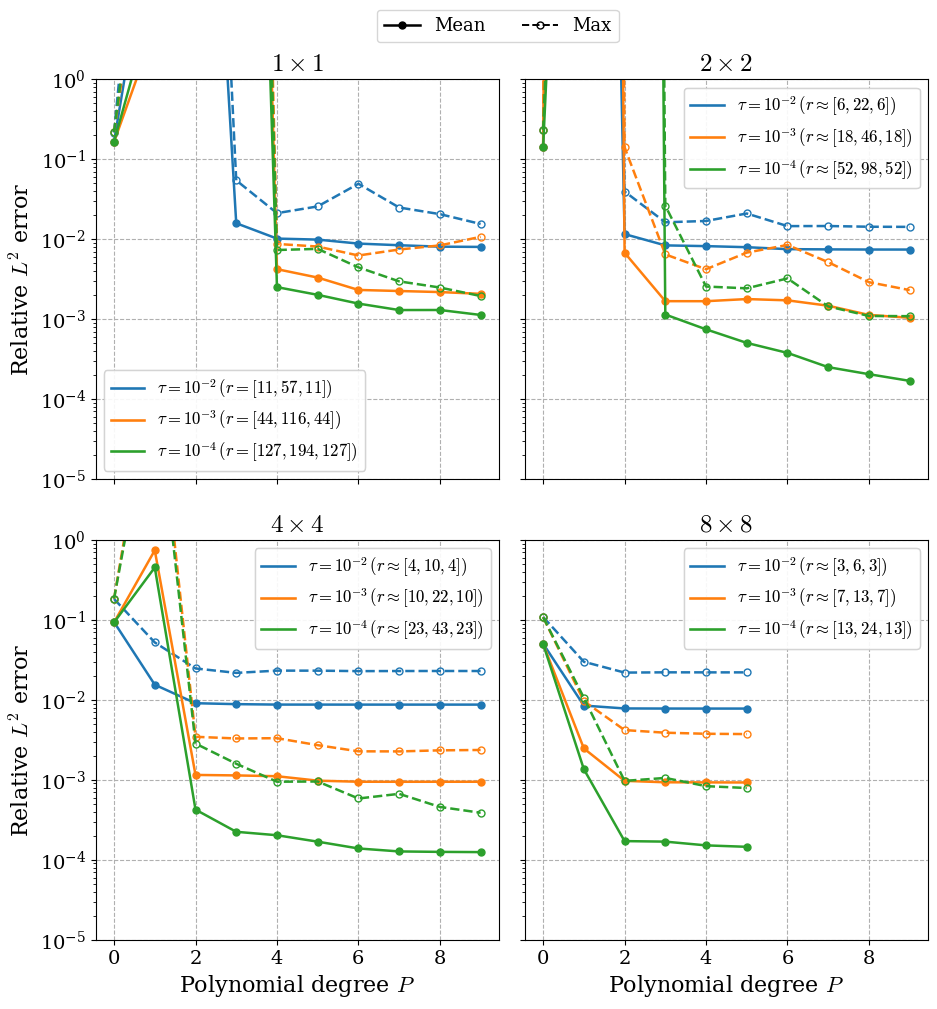

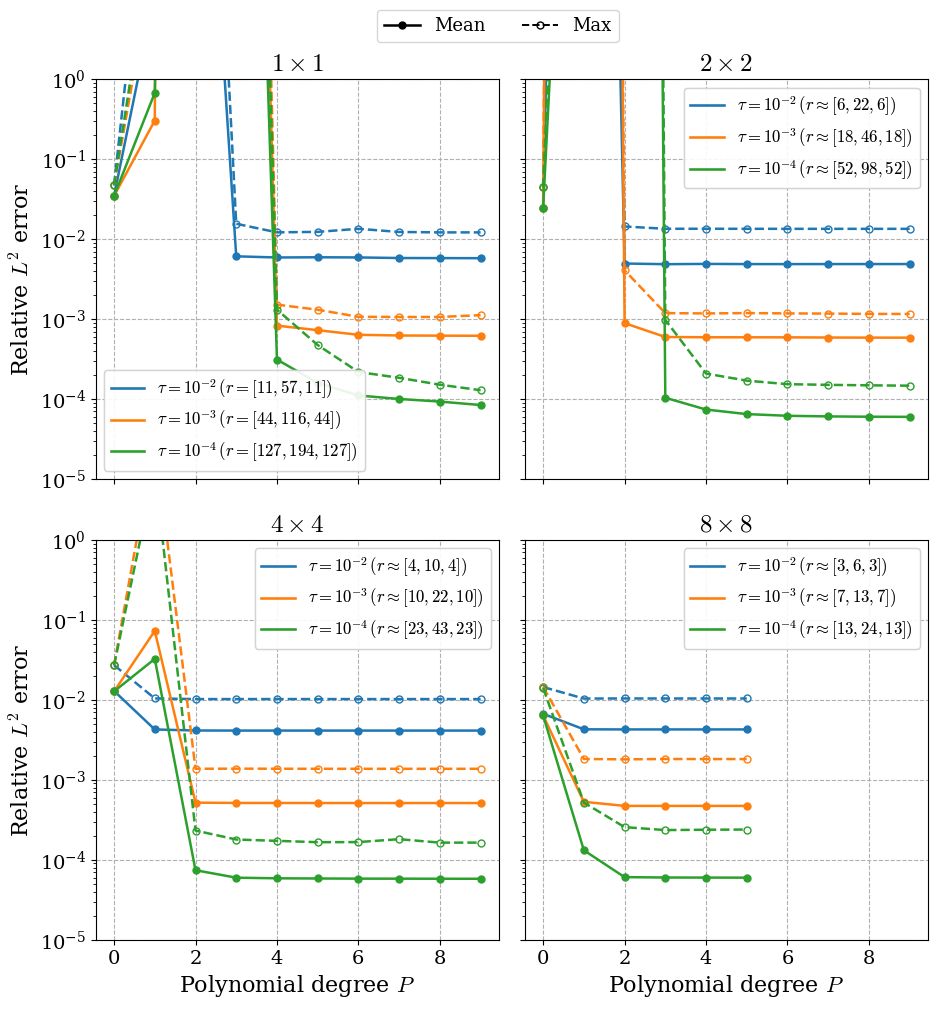

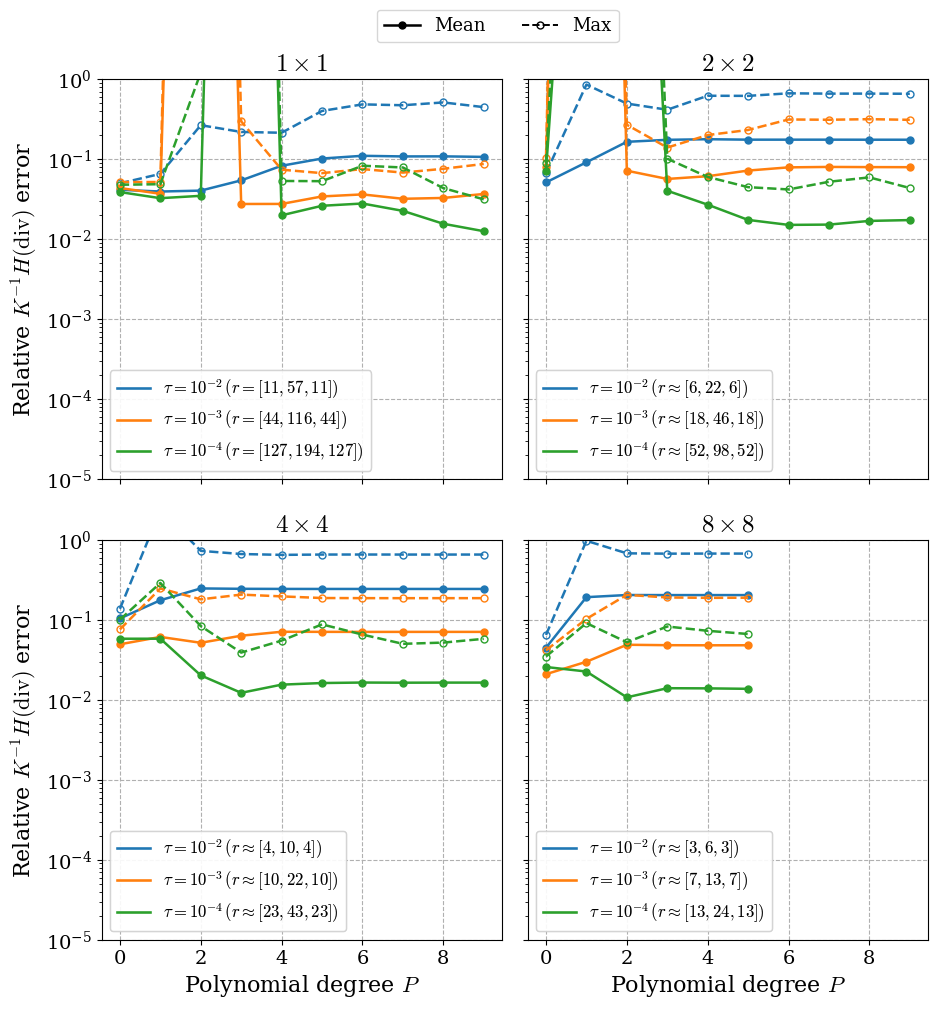

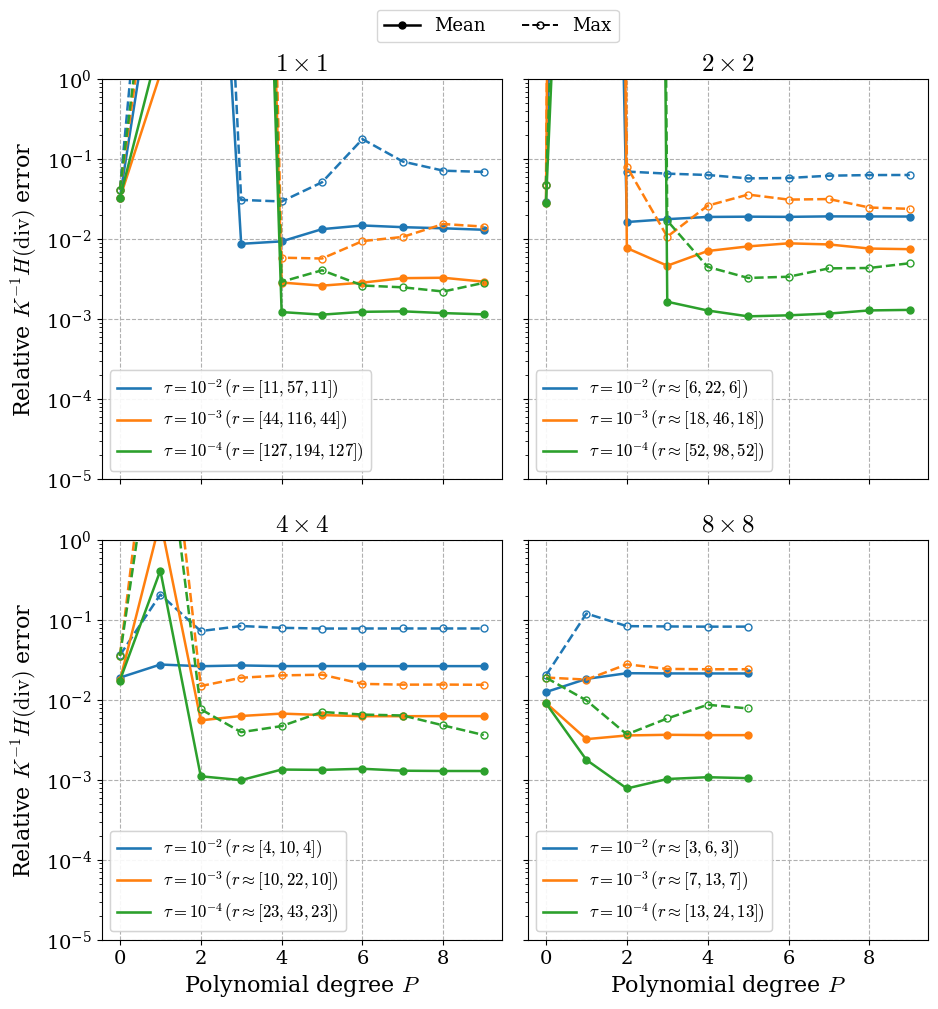

In [1]:
import json
import math
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def validate_no_silent_capped_models(payload):
    regions = payload.get("pod_spectra", {}).get("regions", {})
    results = payload.get("results", {})

    if not regions or not results:
        return

    def _leaf_cap(reg):
        p_cap = reg.get("P_cap_leaf", None)
        if p_cap is not None:
            return int(p_cap)

        n_mu = reg.get("n_mu_train", None)
        if n_mu is None:
            return None

        n_mu = int(n_mu)
        return max(0, int(np.floor(np.sqrt(n_mu))) - 1) if n_mu > 0 else 0

    for tau_key, tau_block in results.items():
        p_list = [int(p) for p in tau_block.get("P", [])]
        for p_req in p_list:
            bad = []
            for leaf_id, reg in regions.items():
                p_cap = _leaf_cap(reg)
                if p_cap is None:
                    continue
                if p_req > p_cap:
                    bad.append((leaf_id, p_cap))

            if bad:
                preview = ", ".join([f"{leaf}(cap={cap})" for leaf, cap in bad[:6]])
                if len(bad) > 6:
                    preview += f", ... (+{len(bad) - 6} more)"
                strict_limit = min(cap for _, cap in bad)
                raise ValueError(
                    f"Detected capped/silent model usage in file: tau={tau_key}, requested P={p_req} exceeds "
                    f"P_cap_leaf in {len(bad)} region(s): {preview}. Use P <= {strict_limit}."
                )



def _leaf_p_cap(reg):
    p_cap = reg.get("P_cap_leaf", None)
    if p_cap is not None:
        return int(p_cap)

    n_mu = reg.get("n_mu_train", None)
    if n_mu is None:
        return None

    n_mu = int(n_mu)
    return max(0, int(np.floor(np.sqrt(n_mu))) - 1) if n_mu > 0 else 0


def is_requested_P_valid_for_all_leaves(payload, P_value):
    regions = payload.get("pod_spectra", {}).get("regions", {})
    if not regions:
        return True

    p_req = int(P_value)
    for reg in regions.values():
        p_cap = _leaf_p_cap(reg)
        if p_cap is None:
            continue
        if p_req > p_cap:
            return False
    return True


def filter_valid_P_values(payload, P_values):
    P_values = np.asarray(P_values, dtype=int)
    if P_values.size == 0:
        return P_values
    mask = np.array([is_requested_P_valid_for_all_leaves(payload, p) for p in P_values], dtype=bool)
    return P_values[mask]


def filter_valid_P_series(payload, P_values, *arrays):
    P_values = np.asarray(P_values, dtype=int)
    if P_values.size == 0:
        outs = [P_values]
        outs.extend(np.asarray(a) for a in arrays)
        return tuple(outs)

    mask = np.array([is_requested_P_valid_for_all_leaves(payload, p) for p in P_values], dtype=bool)
    outs = [P_values[mask]]
    for arr in arrays:
        arr = np.asarray(arr)
        m = min(len(arr), len(mask))
        outs.append(arr[:m][mask[:m]])
    return tuple(outs)


def assert_requested_P_within_leaf_caps(payload, P_value):
    p_req = int(P_value)
    if is_requested_P_valid_for_all_leaves(payload, p_req):
        return p_req
    print(f"Skipping invalid/capped P={p_req} (exceeds leaf admissible degree).")
    return None


def validate_no_silent_capped_models(payload):
    # Non-failing by design: plotting code filters invalid P points explicitly.
    return


plt.rcParams.update({
    "font.family": "serif",
    # Put a guaranteed Matplotlib serif first to avoid sans fallback.
    "font.serif": ["DejaVu Serif", "CMU Serif", "Computer Modern Roman", "Latin Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
})

def format_tau_math(tau):
    s = f"{tau:.15e}"
    mantissa, exponent = s.split("e")
    mantissa = mantissa.rstrip("0").rstrip(".")
    # return f"{mantissa}\\times10^{{{int(exponent)}}}"
    return f"10^{{{int(exponent)}}}"


# ----------------------------
# Load multiple runs
# ----------------------------
# paths = [
#     (r"$1\times 1$", "results_nsplit1_48.json"),
#     (r"$2\times 2$", "results_nsplit2_48.json"),
#     (r"$4\times 4$", "results_nsplit4_48.json"),
#     (r"$8\times 8$", "results_nsplit8_48.json"),
# ]
paths = [
    (r"$1\times 1$", "results_nsplit1.json"),
    (r"$2\times 2$", "results_nsplit2.json"),
    (r"$4\times 4$", "results_nsplit4.json"),
    (r"$8\times 8$", "results_nsplit8.json"),
]

runs = []
for name, path in paths:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    validate_no_silent_capped_models(data)
    runs.append({
        "name": name,
        "cfg": data["config"],
        "results": data["results"],
        "meta": data.get("meta", {}),
        "payload": data,
    })

tau_list = [float(t) for t in runs[0]["cfg"]["tau_list"]]


def average_r_components_per_tau(run):
    out = {}
    res = run["results"]
    for tau in tau_list:
        tau_key = str(tau)
        block = res[tau_key]

        r_p_list = np.asarray(block.get("r_p", []), dtype=float)
        r_u_stab_list = np.asarray(block.get("r_u", []), dtype=float)

        if len(r_p_list) == 0 or len(r_u_stab_list) == 0:
            out[tau] = None
            continue

        # Stored r_u is stabilized velocity size (velocity + supremizers).
        # Using r_s = r_p and r_u = r_u_stab - r_s gives r = [r_p, r_u, r_s].
        r_p = float(np.mean(r_p_list))
        r_s = r_p
        r_u = float(np.mean(r_u_stab_list - r_s))

        out[tau] = (r_p, r_u, r_s)
    return out

def format_r_value(r):
    return f"{r:.2f}".rstrip("0").rstrip(".")

def format_r_triplet(vals):
    if vals is None:
        return "N/A"
    r_p, r_u, r_s = vals
    return f"[{format_r_value(r_p)},{format_r_value(r_u)},{format_r_value(r_s)}]"

# ----------------------------
# Plot helper
# ----------------------------
def plot_metric_grid(
    runs,
    tau_list,
    title,
    key_mean,
    key_max,
    ylabel,
    ylims=(1e-4, 1.0),
    savepath=None,
):
    nplots = len(runs)

    # Force 2x2 layout for 4 runs
    if nplots == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, nplots)
        nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.8 * ncols, 5.2 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes = axes.ravel()
    # fig.suptitle(title, fontsize=20)
    for ax in axes[nplots:]:
        ax.set_visible(False)

    for idx, (ax, run) in enumerate(zip(axes, runs)):
        results = run["results"]
        tau_to_color = {}

        for tau in tau_list:
            tau_key = str(tau)
            Pvals = np.array(results[tau_key]["P"], dtype=int)

            ymean = np.array(results[tau_key][key_mean], dtype=float)
            ymax = np.array(results[tau_key][key_max], dtype=float)
            Pvals, ymean, ymax = filter_valid_P_series(run["payload"], Pvals, ymean, ymax)
            if Pvals.size == 0:
                continue

            l_mean, = ax.semilogy(Pvals, ymean, linestyle="-", marker="o")
            color = l_mean.get_color()
            ax.semilogy(Pvals, ymax, linestyle="--", marker="o", mfc="none", color=color)

            tau_to_color[tau] = color

        ax.set_ylim(*ylims)
        ax.set_title(run["name"])
        ax.grid(True, which="major", ls="--", alpha=1.0)

        # ---- axis labeling logic ----
        row = idx // ncols
        col = idx % ncols

        if row == nrows - 1:
            ax.set_xlabel(r"Polynomial degree $P$")
        if col == 0:
            ax.set_ylabel(ylabel)

        # ---- tau legend ----
        r_dict = average_r_components_per_tau(run)
        tau_handles = []
        tau_labels = []

        is_single_domain = run["cfg"].get("Nsplit", 1) == 1

        for tau in tau_list:
            tau_handles.append(Line2D([0], [0], lw=1.8, color=tau_to_color.get(tau, "k")))
            tau_math = format_tau_math(tau)
            if is_single_domain:
                tau_labels.append(rf"$\tau={tau_math}\,(r={format_r_triplet(r_dict[tau])})$")
            else:
                tau_labels.append(rf"$\tau={tau_math}\,(r\approx {format_r_triplet(r_dict[tau])})$")

        leg_tau = ax.legend(
            tau_handles,
            tau_labels,
            loc="best",
            framealpha=0.7,
        )
        ax.add_artist(leg_tau)

        # ---- mean/max legend ----
        style_handles = [
            Line2D([0], [0], color="k", lw=1.8, linestyle="-", marker="o", label="Mean"),
            Line2D([0], [0], color="k", lw=1.4, linestyle="--", marker="o", mfc="none", label="Max"),
        ]

    style_handles = [
        Line2D([0], [0], color="k", lw=1.8, linestyle="-", marker="o", label="Mean"),
        Line2D([0], [0], color="k", lw=1.4, linestyle="--", marker="o", mfc="none", label="Max"),
    ]
    fig.legend(
        handles=style_handles,
        loc="upper center",
        ncol=2,
        frameon=True,
        fontsize=13,
        bbox_to_anchor=(0.53, 0.98),
    )

    plt.tight_layout(rect=(0, 0, 1, 0.95))

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ----------------------------
# Plot specs
# ----------------------------
plot_specs = [
    dict(
        title=r"Baseline ROM: max-in-time $L^2$ error of $u$",
        key_mean="baseline_u_l2_scaled_l2t_mean",
        key_max="baseline_u_l2_scaled_l2t_max",
        ylabel=r"Relative ${L}^2$ error"
    ),
    dict(
        title=r"Baseline ROM: max-in-time $L^2$ error of $p$",
        key_mean="baseline_p_l2_scaled_l2t_mean",
        key_max="baseline_p_l2_scaled_l2t_max",
        ylabel=r"Relative ${L}^2$ error"
    ),
    dict(
        title=r"CoSTA ROM: max-in-time $L^2$ error of $u$",
        key_mean="costa_u_l2_scaled_l2t_mean",
        key_max="costa_u_l2_scaled_l2t_max",
        ylabel=r"Relative ${L}^2$ error"
    ),
    dict(
        title=r"CoSTA ROM: max-in-time $L^2$ error of $p$",
        key_mean="costa_p_l2_scaled_l2t_mean",
        key_max="costa_p_l2_scaled_l2t_max",
        ylabel=r"Relative ${L}^2$ error"
    ),
    dict(
        title=r"Baseline ROM: max-in-time $K^{-1}H(\mathrm{div})$ error of $u$",
        key_mean="baseline_u_khdiv_scaled_l2t_mean",
        key_max="baseline_u_khdiv_scaled_l2t_max",
        ylabel=r"Relative $K^{-1}H(\mathrm{div})$ error"
    ),
    dict(
        title=r"CoSTA ROM: max-in-time $K^{-1}H(\mathrm{div})$ error of $u$",
        key_mean="costa_u_khdiv_scaled_l2t_mean",
        key_max="costa_u_khdiv_scaled_l2t_max",
        ylabel=r"Relative $K^{-1}H(\mathrm{div})$ error"
    ),
]

save_dir = "figs"
problem = "var_K"
os.makedirs(save_dir, exist_ok=True)

for i, spec in enumerate(plot_specs, start=1):
    # savepath = os.path.join(save_dir, f"{i:02d}_{spec['key_mean']}_grid_{problem}.pdf")
    savepath = os.path.join(save_dir, f"{spec['key_mean']}_grid_{problem}.pdf")
    # print(savepath)
    # savepath=None

    plot_metric_grid(
        runs=runs,
        tau_list=tau_list,
        title=spec["title"],
        key_mean=spec["key_mean"],
        key_max=spec["key_max"],
        ylabel=spec["ylabel"],
        ylims=(1e-5, 1.0),
        savepath=savepath
    )



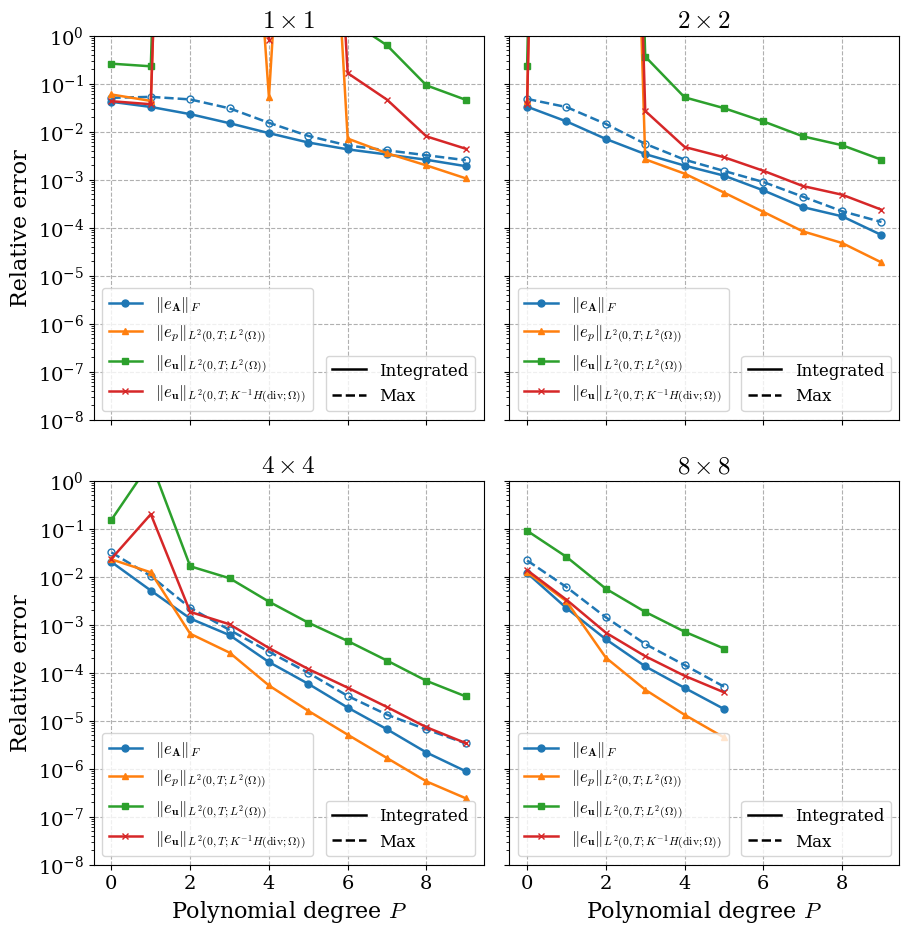

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _leaf_p_cap(reg):
    p_cap = reg.get("P_cap_leaf", None)
    if p_cap is not None:
        return int(p_cap)

    n_mu = reg.get("n_mu_train", None)
    if n_mu is None:
        return None

    n_mu = int(n_mu)
    return max(0, int(np.floor(np.sqrt(n_mu))) - 1) if n_mu > 0 else 0


def is_requested_P_valid_for_all_leaves(payload, P_value):
    regions = payload.get("pod_spectra", {}).get("regions", {})
    if not regions:
        return True

    p_req = int(P_value)
    for reg in regions.values():
        p_cap = _leaf_p_cap(reg)
        if p_cap is None:
            continue
        if p_req > p_cap:
            return False
    return True


def filter_valid_P_values(payload, P_values):
    P_values = np.asarray(P_values, dtype=int)
    if P_values.size == 0:
        return P_values
    mask = np.array([is_requested_P_valid_for_all_leaves(payload, p) for p in P_values], dtype=bool)
    return P_values[mask]


def filter_valid_P_series(payload, P_values, *arrays):
    P_values = np.asarray(P_values, dtype=int)
    if P_values.size == 0:
        outs = [P_values]
        outs.extend(np.asarray(a) for a in arrays)
        return tuple(outs)

    mask = np.array([is_requested_P_valid_for_all_leaves(payload, p) for p in P_values], dtype=bool)
    outs = [P_values[mask]]
    for arr in arrays:
        arr = np.asarray(arr)
        m = min(len(arr), len(mask))
        outs.append(arr[:m][mask[:m]])
    return tuple(outs)


def assert_requested_P_within_leaf_caps(payload, P_value):
    p_req = int(P_value)
    if is_requested_P_valid_for_all_leaves(payload, p_req):
        return p_req
    print(f"Skipping invalid/capped P={p_req} (exceeds leaf admissible degree).")
    return None


def validate_no_silent_capped_models(payload):
    # Non-failing by design: plotting code filters invalid P points explicitly.
    return


# plt.rcParams.update({
#     "font.family": "serif",
#     "font.size": 14,
#     "axes.labelsize": 16,
#     "axes.titlesize": 18,
#     "xtick.labelsize": 14,
#     "ytick.labelsize": 14,
#     "legend.fontsize": 11,
#     "lines.linewidth": 1.8,
#     "lines.markersize": 5,
# })

# ----------------------------
# Load runs
# ----------------------------
paths = [
    (r"$1\times 1$", "results_nsplit1.json"),
    (r"$2\times 2$", "results_nsplit2.json"),
    (r"$4\times 4$", "results_nsplit4.json"),
    (r"$8\times 8$", "results_nsplit8.json"),
]

runs = []
for name, path in paths:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    validate_no_silent_capped_models(data)

    runs.append({
        "name": name,
        "cfg": data.get("config", {}),
        "results": data.get("results", {}),
        "direct_muu_l2fit_errors": data.get("direct_muu_l2fit_errors", {}),
        "meta": data.get("meta", {}),
        "payload": data,
    })

# ----------------------------
# Metrics to overlay in each subplot
# mean key (solid) + max key (dotted)
# ----------------------------
plot_specs = [
    dict(
        mean_key="muu_over_fullA_fro_rel",
        max_key="muu_over_fullA_fro_rel_maxmu",
        label=r"$\| e_{\mathbf{A}} \|_{F}$",
        marker="o",
    ),
    dict(
        mean_key="p_l2_rel",
        max_key="p_l2_rel_l2t_maxmu",
        label=r"$\| e_p \|_{L^2(0,T;L^2(\Omega))}$",
        marker="^",
    ),
    dict(
        mean_key="u_l2_rel",
        max_key="u_l2_rel_l2t_maxmu",
        label=r"$\| e_{\mathbf{u}} \|_{L^2(0,T;L^2(\Omega))}$",
        marker="s",
    ),
    # dict(
    #     mean_key="u_hdiv_rel",
    #     max_key="u_hdiv_rel_maxt_maxmu",
    #     label=r"$\| e_{\mathbf{u}} \|_{H(\mathrm{div})}$",
    #     marker="d",
    # ),
    dict(
        mean_key="u_khdiv_rel",
        max_key="u_khdiv_rel_l2t_maxmu",
        label=r"$\| e_{\mathbf{u}} \|_{L^2(0,T;K^{-1}H(\mathrm{div};\Omega))}$",
        marker="x",
    ),
]


# ----------------------------
# Plot helper:
# 2x2 grid, one subplot per run,
# with all error curves overlaid in each subplot
# ----------------------------
def plot_direct_fit_overlay_grid(
    runs,
    plot_specs,
    title=r"Direct $L^2$-fit errors",
    ylabel="Relative error",
    ylims=(1e-8, 1.0),
    savepath=None,
    panel_width=4.8,
    panel_height=5.2,
):
    if len(runs) != 4:
        raise ValueError("This function expects exactly 4 runs for a 2x2 grid.")

    nrows, ncols = 2, 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(2 * panel_width, 2 * panel_height),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for idx, (ax, run) in enumerate(zip(axes, runs)):
        fitres = run.get("direct_muu_l2fit_errors", {})

        ax.set_title(run["name"])
        ax.set_ylim(*ylims)
        ax.grid(True, which="major", ls="--", alpha=1.0)

        row = idx // ncols
        col = idx % ncols

        if row == nrows - 1:
            ax.set_xlabel(r"Polynomial degree $P$")

        if col == 0:
            ax.set_ylabel(ylabel)

        if not fitres:
            ax.text(
                0.5, 0.5, "No direct fit data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=13,
            )
            continue

        Pvals = np.array(sorted(int(k) for k in fitres.keys()), dtype=int)
        Pvals = filter_valid_P_values(run["payload"], Pvals)
        if Pvals.size == 0:
            ax.text(0.5, 0.5, "No valid P points", transform=ax.transAxes, ha="center", va="center", fontsize=13)
            continue

        # metric legend (color/marker = metric)
        metric_handles = []

        # overlay mean + max for each metric
        for spec in plot_specs:
            mean_key = spec["mean_key"]
            max_key = spec["max_key"]
            label = spec["label"]
            marker = spec.get("marker", "o")

            x_mean, y_mean = [], []
            x_max, y_max = [], []

            for P in Pvals:
                entry = fitres[str(P)]

                if mean_key in entry and entry[mean_key] is not None:
                    x_mean.append(P)
                    y_mean.append(float(entry[mean_key]))

                if max_key in entry and entry[max_key] is not None:
                    x_max.append(P)
                    y_max.append(float(entry[max_key]))

            if len(x_mean) == 0 and len(x_max) == 0:
                continue

            color = None
            if len(x_mean) > 0:
                line_mean, = ax.semilogy(
                    x_mean,
                    y_mean,
                    linestyle="-",
                    marker=marker,
                    label=label,
                )
                color = line_mean.get_color()
                metric_handles.append(
                    Line2D([0], [0], color=color, lw=1.8, marker=marker, linestyle="-", label=label)
                )

            if len(x_max) > 0:
                if color is None:
                    line_max, = ax.semilogy(
                        x_max,
                        y_max,
                        linestyle="--",
                        marker=marker,
                        mfc="none",
                        label=None,
                    )
                    color = line_max.get_color()
                    metric_handles.append(
                        Line2D([0], [0], color=color, lw=1.8, marker=marker, linestyle="-", label=label)
                    )
                else:
                    ax.semilogy(
                        x_max,
                        y_max,
                        linestyle="--",
                        marker=marker,
                        mfc="none",
                        color=color,
                        label=None,
                    )

        # legend 1: metrics (color/marker)
        if metric_handles:
            leg_metrics = ax.legend(handles=metric_handles, loc="lower left", frameon=True)
            ax.add_artist(leg_metrics)

        # legend 2: line style meaning
        style_handles = [
            Line2D([0], [0], color="k", lw=1.8, linestyle="-", label="Integrated"),
            Line2D([0], [0], color="k", lw=1.8, linestyle="--", label="Max"),
        ]
        ax.legend(handles=style_handles, loc="lower right", frameon=True)

    plt.tight_layout(rect=[0.03, 0.03, 1.00, 0.95])

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ----------------------------
# Make the single 2x2 figure
# ----------------------------
savepath = "figs/l2_fit_error.pdf"
plot_direct_fit_overlay_grid(
    runs=runs,
    plot_specs=plot_specs,
    title=r"Direct $L^2$-fit errors for each domain split",
    ylabel="Relative error",
    ylims=(1e-8, 1.0),
    savepath=savepath,
    panel_width=4.8,
    panel_height=5.2,
)



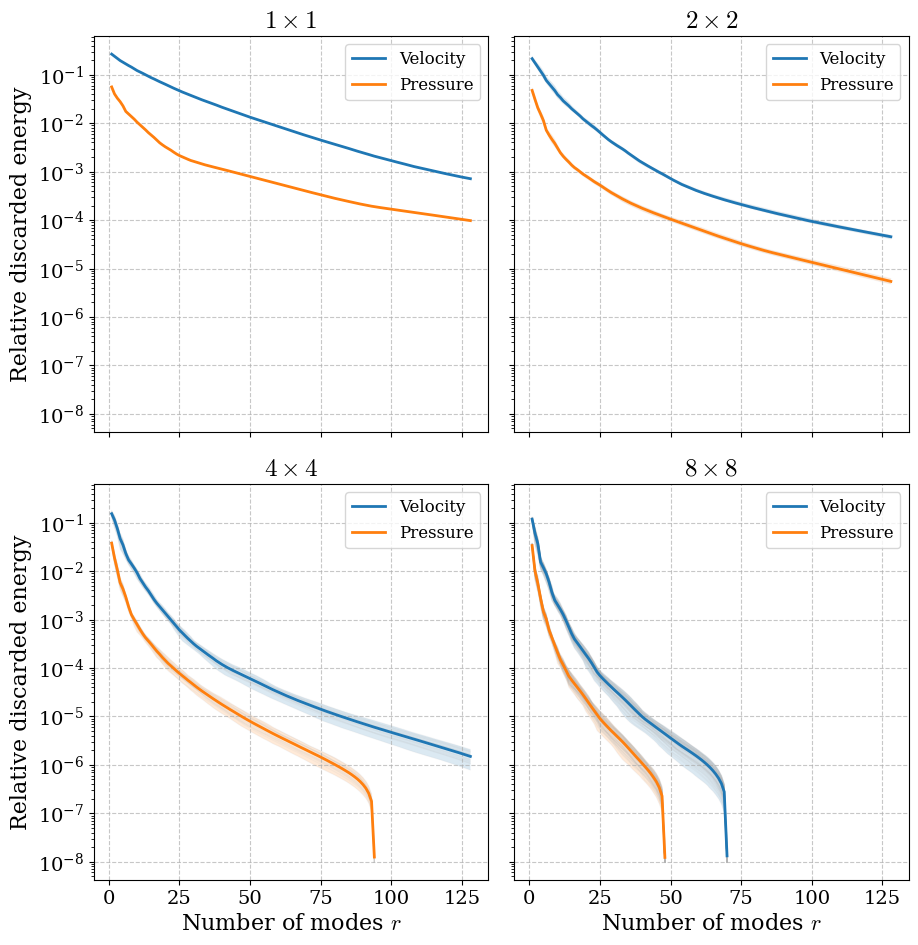

$1\times 1$: u_regions=1, p_regions=1, u_common_modes=200, p_common_modes=200, u_used=128, p_used=128
$2\times 2$: u_regions=4, p_regions=4, u_common_modes=200, p_common_modes=200, u_used=128, p_used=128
$4\times 4$: u_regions=16, p_regions=16, u_common_modes=150, p_common_modes=94, u_used=128, p_used=94
$8\times 8$: u_regions=64, p_regions=64, u_common_modes=70, p_common_modes=48, u_used=70, p_used=48


In [3]:
import json
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def validate_no_silent_capped_models(payload):
    regions = payload.get("pod_spectra", {}).get("regions", {})
    results = payload.get("results", {})

    if not regions or not results:
        return

    def _leaf_cap(reg):
        p_cap = reg.get("P_cap_leaf", None)
        if p_cap is not None:
            return int(p_cap)

        n_mu = reg.get("n_mu_train", None)
        if n_mu is None:
            return None

        n_mu = int(n_mu)
        return max(0, int(np.floor(np.sqrt(n_mu))) - 1) if n_mu > 0 else 0

    for tau_key, tau_block in results.items():
        p_list = [int(p) for p in tau_block.get("P", [])]
        for p_req in p_list:
            bad = []
            for leaf_id, reg in regions.items():
                p_cap = _leaf_cap(reg)
                if p_cap is None:
                    continue
                if p_req > p_cap:
                    bad.append((leaf_id, p_cap))

            if bad:
                preview = ", ".join([f"{leaf}(cap={cap})" for leaf, cap in bad[:6]])
                if len(bad) > 6:
                    preview += f", ... (+{len(bad) - 6} more)"
                strict_limit = min(cap for _, cap in bad)
                raise ValueError(
                    f"Detected capped/silent model usage in file: tau={tau_key}, requested P={p_req} exceeds "
                    f"P_cap_leaf in {len(bad)} region(s): {preview}. Use P <= {strict_limit}."
                )


# ============================================================
# Helpers
# ============================================================
def load_payload(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def _region_sort_key(k):
    try:
        return (0, int(k))
    except (TypeError, ValueError):
        return (1, str(k))


def get_region_spectra(payload, field="u_svals_full", normalize=False):
    regions = payload["pod_spectra"]["regions"]
    if not regions:
        raise ValueError("No pod_spectra['regions'] found in JSON.")

    spectra = {}
    for region_id, meta in regions.items():
        s = np.asarray(meta[field], dtype=float)

        if s.size == 0:
            continue

        if normalize:
            s = s / max(abs(s[0]), 1e-30)

        spectra[region_id] = s

    if not spectra:
        raise ValueError(f"No non-empty spectra found for field={field!r}.")

    return spectra


def truncate_spectra_to_common_length(spectra, max_modes=None):
    lengths = [len(s) for s in spectra.values()]
    common_len = min(lengths)

    if max_modes is None:
        m = common_len
    else:
        m = min(int(max_modes), common_len)

    keys_sorted = sorted(spectra.keys(), key=_region_sort_key)
    S_full = np.vstack([spectra[k][:common_len] for k in keys_sorted])

    return keys_sorted, S_full, m, common_len


def compute_discarded_energy_statistics(S):
    denom = np.sum(S**2, axis=1, keepdims=True)
    denom = np.maximum(denom, 1e-30)

    retained = np.cumsum(S**2, axis=1) / denom
    discarded = np.sqrt(np.maximum(1.0 - retained, 1e-16))

    d_min = np.min(discarded, axis=0)
    d_mean = np.mean(discarded, axis=0)
    d_max = np.max(discarded, axis=0)

    return {
        "discarded": discarded,
        "d_min": d_min,
        "d_mean": d_mean,
        "d_max": d_max,
    }


# ============================================================
# Plotter: overlay velocity + pressure discarded-energy envelopes
# ============================================================
def plot_regional_discarded_energy_grid_both(
    paths,
    fields=("u_svals_full", "p_svals_full"),
    normalize=False,
    max_modes=128,
    show_all_regions_faint=True,
    logy=True,
    panel_width=4.8,
    panel_height=5.2,
    save_pdf=True,
    pdf_path=None,
):
    if len(fields) != 2:
        raise ValueError("fields must contain exactly two entries: velocity and pressure")

    labels = {
        "u_svals_full": "Velocity",
        "p_svals_full": "Pressure",
    }





    runs = []
    for name, json_path in paths:
        payload = load_payload(json_path)

        field_data = {}
        for field in fields:
            spectra = get_region_spectra(payload=payload, field=field, normalize=normalize)
            keys_sorted, S_full, m, common_len = truncate_spectra_to_common_length(
                spectra=spectra,
                max_modes=max_modes,
            )
            stats = compute_discarded_energy_statistics(S_full)
            field_data[field] = {
                "keys_sorted": keys_sorted,
                "S_full": S_full,
                "m": m,
                "common_len": common_len,
                "stats": stats,
            }

        runs.append({
            "name": name,
            "json_path": json_path,
            "fields": field_data,
        })

    nplots = len(runs)
    if nplots == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, nplots)
        nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax in axes[nplots:]:
        ax.set_visible(False)

    for idx, (ax, run) in enumerate(zip(axes, runs)):
        for field in fields:
            fd = run["fields"][field]
            m_field = int(fd["m"])
            x_field = np.arange(1, m_field + 1)
            stats = fd["stats"]

            discarded = stats["discarded"][:, :m_field]
            d_min_view = stats["d_min"][:m_field]
            d_mean_view = stats["d_mean"][:m_field]
            d_max_view = stats["d_max"][:m_field]

            c_env = None
            c_mean = None

            if show_all_regions_faint:
                for row in discarded:
                    ax.plot(x_field, row, color="0.7", alpha=0.10, linewidth=0.8)

            h_mean, = ax.plot(x_field, d_mean_view, linewidth=2.0)
            mean_color = h_mean.get_color()
            ax.fill_between(x_field, d_min_view, d_max_view, facecolor=mean_color, alpha=0.16)


        if logy:
            ax.set_yscale("log")

        ax.set_title(run["name"])
        ax.grid(True, which="major", ls="--", alpha=0.7)

        row = idx // ncols
        col = idx % ncols
        if row == nrows - 1:
            ax.set_xlabel(r"Number of modes $r$")
        if col == 0:
            ax.set_ylabel("Relative discarded energy")

        # if idx == 0:
        if 0 == 0:
            legend_handles = [
                # Patch(facecolor="C0", alpha=0.16, edgecolor="none", label=f"{labels.get(fields[0], fields[0])} envelope"),
                Line2D([0], [0], color="C0", lw=2.0, label=f"{labels.get(fields[0], fields[0])}"),
                # Patch(facecolor="C1", alpha=0.16, edgecolor="none", label=f"{labels.get(fields[1], fields[1])} envelope"),
                Line2D([0], [0], color="C1", lw=2.0, label=f"{labels.get(fields[1], fields[1])}"),
            ]
            ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    title = f"Regional sqrt relative discarded energy ({fields[0]} + {fields[1]})"
    if normalize:
        title += " (normalized)"

    plt.tight_layout(rect=[0.02, 0.02, 1.00, 0.95])
    if save_pdf:
        if pdf_path is None:
            suffix = "normalized" if normalize else "raw"
            pdf_file = Path(f"figs/regional_discarded_energy_both_{suffix}.pdf")
        else:
            pdf_file = Path(pdf_path)
            if pdf_file.suffix.lower() != ".pdf":
                pdf_file = pdf_file.with_suffix(".pdf")

        pdf_file.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(pdf_file, format="pdf", bbox_inches="tight")

    plt.show()

    for run in runs:
        u = run["fields"][fields[0]]
        p = run["fields"][fields[1]]
        print(
            f"{run['name']}: "
            f"u_regions={len(u['keys_sorted'])}, p_regions={len(p['keys_sorted'])}, "
            f"u_common_modes={u['common_len']}, p_common_modes={p['common_len']}, "
            f"u_used={u['m']}, p_used={p['m']}"
        )


# ============================================================
paths = [
    (r"$1\times 1$", "results_nsplit1.json"),
    (r"$2\times 2$", "results_nsplit2.json"),
    (r"$4\times 4$", "results_nsplit4.json"),
    (r"$8\times 8$", "results_nsplit8.json"),
]

fields = ("u_svals_full", "p_svals_full")
normalize = False
max_modes = 128
show_all_regions_faint = True
logy = True
pdf_path = "figs/discarded_energy.pdf"

plot_regional_discarded_energy_grid_both(
    paths=paths,
    fields=fields,
    normalize=normalize,
    max_modes=max_modes,
    show_all_regions_faint=show_all_regions_faint,
    logy=logy,
    panel_width=4.8,
    panel_height=5.2,
    pdf_path=pdf_path,
)


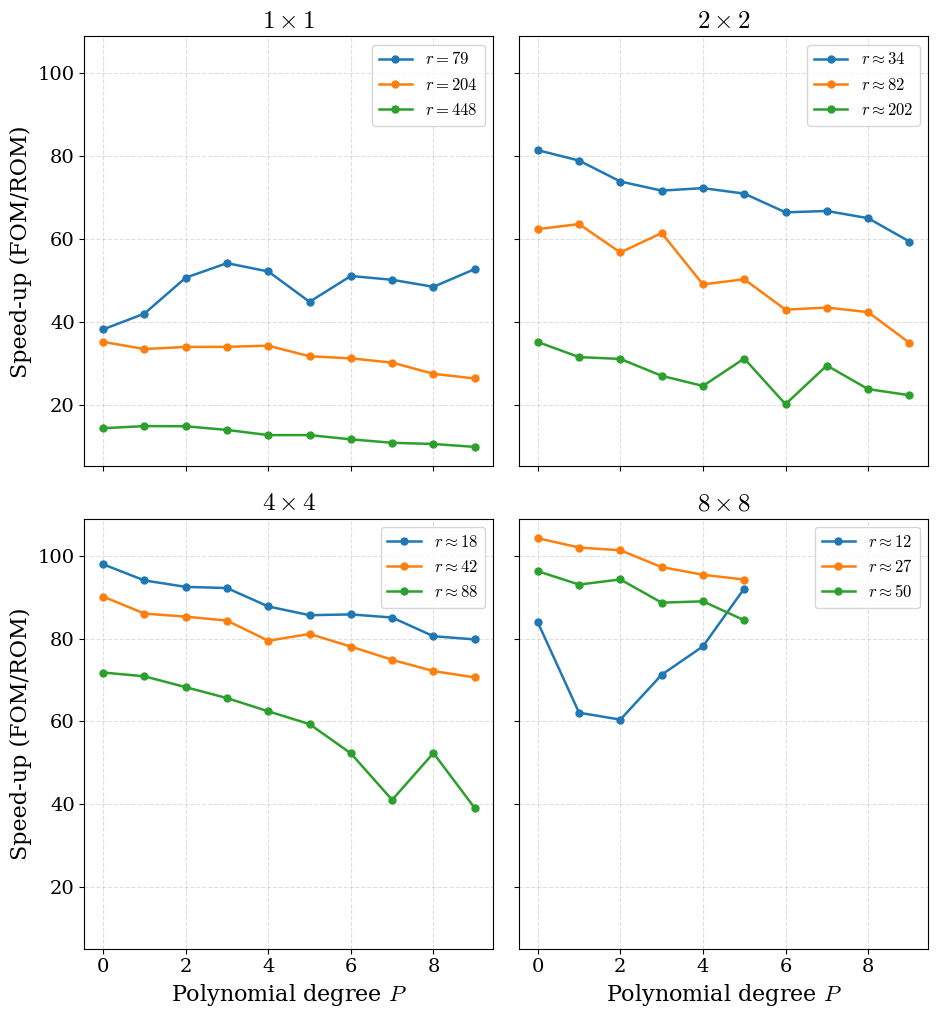

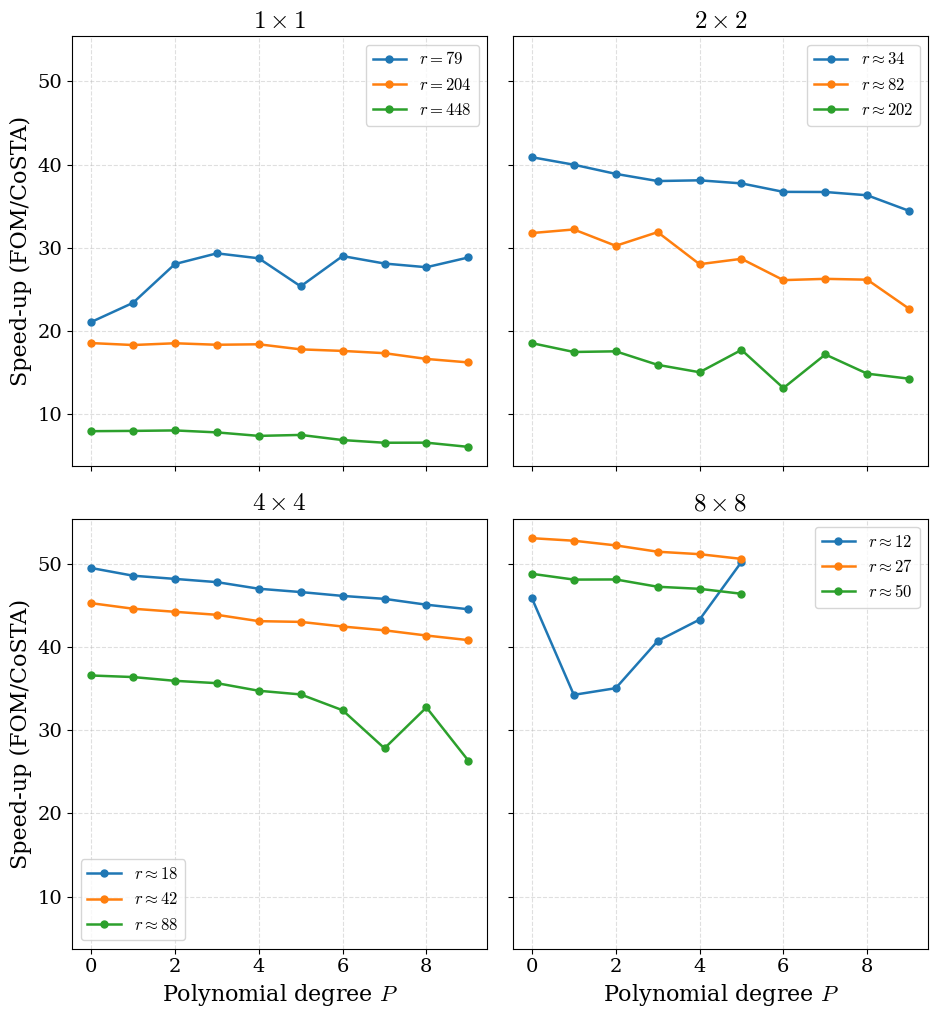

In [4]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def validate_no_silent_capped_models(payload):
    regions = payload.get("pod_spectra", {}).get("regions", {})
    results = payload.get("results", {})

    if not regions or not results:
        return

    def _leaf_cap(reg):
        p_cap = reg.get("P_cap_leaf", None)
        if p_cap is not None:
            return int(p_cap)

        n_mu = reg.get("n_mu_train", None)
        if n_mu is None:
            return None

        n_mu = int(n_mu)
        return max(0, int(np.floor(np.sqrt(n_mu))) - 1) if n_mu > 0 else 0

    for tau_key, tau_block in results.items():
        p_list = [int(p) for p in tau_block.get("P", [])]
        for p_req in p_list:
            bad = []
            for leaf_id, reg in regions.items():
                p_cap = _leaf_cap(reg)
                if p_cap is None:
                    continue
                if p_req > p_cap:
                    bad.append((leaf_id, p_cap))

            if bad:
                preview = ", ".join([f"{leaf}(cap={cap})" for leaf, cap in bad[:6]])
                if len(bad) > 6:
                    preview += f", ... (+{len(bad) - 6} more)"
                strict_limit = min(cap for _, cap in bad)
                raise ValueError(
                    f"Detected capped/silent model usage in file: tau={tau_key}, requested P={p_req} exceeds "
                    f"P_cap_leaf in {len(bad)} region(s): {preview}. Use P <= {strict_limit}."
                )




def _leaf_p_cap(reg):
    p_cap = reg.get("P_cap_leaf", None)
    if p_cap is not None:
        return int(p_cap)

    n_mu = reg.get("n_mu_train", None)
    if n_mu is None:
        return None

    n_mu = int(n_mu)
    return max(0, int(np.floor(np.sqrt(n_mu))) - 1) if n_mu > 0 else 0


def is_requested_P_valid_for_all_leaves(payload, P_value):
    regions = payload.get("pod_spectra", {}).get("regions", {})
    if not regions:
        return True

    p_req = int(P_value)
    for reg in regions.values():
        p_cap = _leaf_p_cap(reg)
        if p_cap is None:
            continue
        if p_req > p_cap:
            return False
    return True


def filter_valid_P_values(payload, P_values):
    P_values = np.asarray(P_values, dtype=int)
    if P_values.size == 0:
        return P_values
    mask = np.array([is_requested_P_valid_for_all_leaves(payload, p) for p in P_values], dtype=bool)
    return P_values[mask]


def filter_valid_P_series(payload, P_values, *arrays):
    P_values = np.asarray(P_values, dtype=int)
    if P_values.size == 0:
        outs = [P_values]
        outs.extend(np.asarray(a) for a in arrays)
        return tuple(outs)

    mask = np.array([is_requested_P_valid_for_all_leaves(payload, p) for p in P_values], dtype=bool)
    outs = [P_values[mask]]
    for arr in arrays:
        arr = np.asarray(arr)
        m = min(len(arr), len(mask))
        outs.append(arr[:m][mask[:m]])
    return tuple(outs)


def assert_requested_P_within_leaf_caps(payload, P_value):
    p_req = int(P_value)
    if is_requested_P_valid_for_all_leaves(payload, p_req):
        return p_req
    print(f"Skipping invalid/capped P={p_req} (exceeds leaf admissible degree).")
    return None


def validate_no_silent_capped_models(payload):
    # Non-failing by design: plotting code filters invalid P points explicitly.
    return


def format_tau_math(tau):
    s = f"{tau:.15e}"
    mantissa, exponent = s.split("e")
    mantissa = mantissa.rstrip("0").rstrip(".")
    return rf"10^{{{int(exponent)}}}"


def average_r_components_per_tau(run, tau_list):
    out = {}
    res = run["results"]
    for tau in tau_list:
        tau_key = str(tau)
        block = res.get(tau_key, {})

        r_p_list = np.asarray(block.get("r_p", []), dtype=float)
        r_u_stab_list = np.asarray(block.get("r_u", []), dtype=float)

        if len(r_p_list) == 0 or len(r_u_stab_list) == 0:
            out[tau] = None
            continue

        # Stored r_u is stabilized velocity size (velocity + supremizers).
        # Using r_s = r_p and r_u = r_u_stab - r_s gives r = [r_p, r_u, r_s].
        r_p = float(np.mean(r_p_list))
        r_s = r_p
        r_u = float(np.mean(r_u_stab_list - r_s))
        out[tau] = (r_p, r_u, r_s)
    return out

def average_r_tot_per_tau(run, tau_list):
    out = {}
    res = run["results"]
    for tau in tau_list:
        tau_key = str(tau)
        block = res.get(tau_key, {})
        r_tot_list = np.asarray(block.get("r_tot", []), dtype=float)
        out[tau] = float(np.mean(r_tot_list)) if len(r_tot_list) > 0 else None
    return out

def format_r_value(r):
    return f"{r:.2f}".rstrip("0").rstrip(".")

def format_r_triplet(vals):
    if vals is None:
        return "N/A"
    r_p, r_u, r_s = vals
    return f"[{format_r_value(r_p)},{format_r_value(r_u)},{format_r_value(r_s)}]"

def resolve_speedup_key(block, requested_key):
    if requested_key in block:
        return requested_key
    fallback = {
        "rom_speedup_avg": ["rom_speedup_throughput", "rom_speedup"],
        "costa_speedup_avg": ["costa_speedup_throughput", "costa_speedup"],
    }
    for k in fallback.get(requested_key, []):
        if k in block:
            return k
    return None


# ------------------------------------------------------------
# Load runs
# ------------------------------------------------------------
paths = [
    (r"$1 \times 1$", "results_nsplit1.json"),
    (r"$2 \times 2$", "results_nsplit2.json"),
    (r"$4 \times 4$", "results_nsplit4.json"),
    (r"$8 \times 8$", "results_nsplit8.json"),
]

runs = []
for name, path in paths:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    validate_no_silent_capped_models(data)
    runs.append({
        "name": name,
        "cfg": data.get("config", {}),
        "results": data.get("results", {}),
        "payload": data,
    })

if not runs:
    raise ValueError("No runs loaded.")

tau_list = [float(t) for t in runs[0]["cfg"]["tau_list"]]


# ------------------------------------------------------------
# Plot helper: one panel per Nsplit, one curve per tau
# ------------------------------------------------------------
def plot_speedup_grid(
    runs,
    tau_list,
    speedup_key,
    ylabel="Speedup",
    yscale=None,
    panel_width=4.8,
    panel_height=5.2,
    savepath=None,
):
    nplots = len(runs)
    if nplots == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, nplots)
        nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax in axes[nplots:]:
        ax.set_visible(False)

    for idx, (ax, run) in enumerate(zip(axes, runs)):
        results = run["results"]
        r_dict = average_r_components_per_tau(run, tau_list)
        r_tot_dict = average_r_tot_per_tau(run, tau_list)
        is_single_domain = run["cfg"].get("Nsplit", 1) == 1

        ax.set_title(run["name"])
        ax.grid(True, which="both", ls="--", alpha=0.4)

        if yscale:
            ax.set_yscale(yscale)

        row = idx // ncols
        col = idx % ncols
        if row == nrows - 1:
            ax.set_xlabel(r"Polynomial degree $P$")
        if col == 0:
            ax.set_ylabel(ylabel)

        plotted_any = False

        for tau in tau_list:
            tau_key = str(tau)
            if tau_key not in results:
                continue

            Pvals = np.asarray(results[tau_key].get("P", []), dtype=int)
            speedup_key_resolved = resolve_speedup_key(results[tau_key], speedup_key)
            if speedup_key_resolved is None:
                continue
            # sp = np.asarray(results[tau_key].get(speedup_key, []), dtype=float)
            sp = np.asarray(results[tau_key].get(speedup_key_resolved, []), dtype=float)

            if Pvals.size == 0 or sp.size == 0:
                continue

            m = min(Pvals.size, sp.size)
            Pvals = Pvals[:m]
            sp = sp[:m]
            Pvals, sp = filter_valid_P_series(run["payload"], Pvals, sp)
            if Pvals.size == 0:
                continue

            tau_math = format_tau_math(tau)
            ax.plot(
                Pvals,
                sp,
                marker="o",
                # label=rf"$\tau={tau_math}\,(r\approx {format_r_value(r_dict[tau])})$",
                # label=rf"$r={format_r_triplet(r_dict[tau])}$" if is_single_domain else rf"$r\approx {format_r_triplet(r_dict[tau])}$",
                # label=rf"$r={format_r_triplet(r_dict[tau])}$" if is_single_domain else rf"$r\approx {format_r_triplet(r_dict[tau])}$",
                label=rf"$r={format_r_value(r_tot_dict[tau])}$" if (is_single_domain and r_tot_dict[tau] is not None) else (rf"$r\approx {format_r_value(r_tot_dict[tau])}$" if r_tot_dict[tau] is not None else r"$r=\mathrm{N/A}$"),
            )
            plotted_any = True

        if plotted_any:
            ax.legend(loc="best", frameon=True)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ------------------------------------------------------------
# Baseline ROM speedup (FOM/ROM)
# ------------------------------------------------------------
savepath = "figs/baseline_speedup.pdf"
# savepath=None
plot_speedup_grid(
    runs=runs,
    tau_list=tau_list,
    speedup_key="rom_speedup_avg",
    ylabel=r"Speed-up (FOM/ROM)",
    yscale=None,
    savepath=savepath,
)

# ------------------------------------------------------------
# CoSTA ROM speedup (FOM/CoSTA)
# ------------------------------------------------------------
savepath = "figs/costa_speedup.pdf"
# savepath=None
plot_speedup_grid(
    runs=runs,
    tau_list=tau_list,
    speedup_key="costa_speedup_avg",
    ylabel=r"Speed-up (FOM/CoSTA)",
    yscale=None,
    savepath=savepath,
)



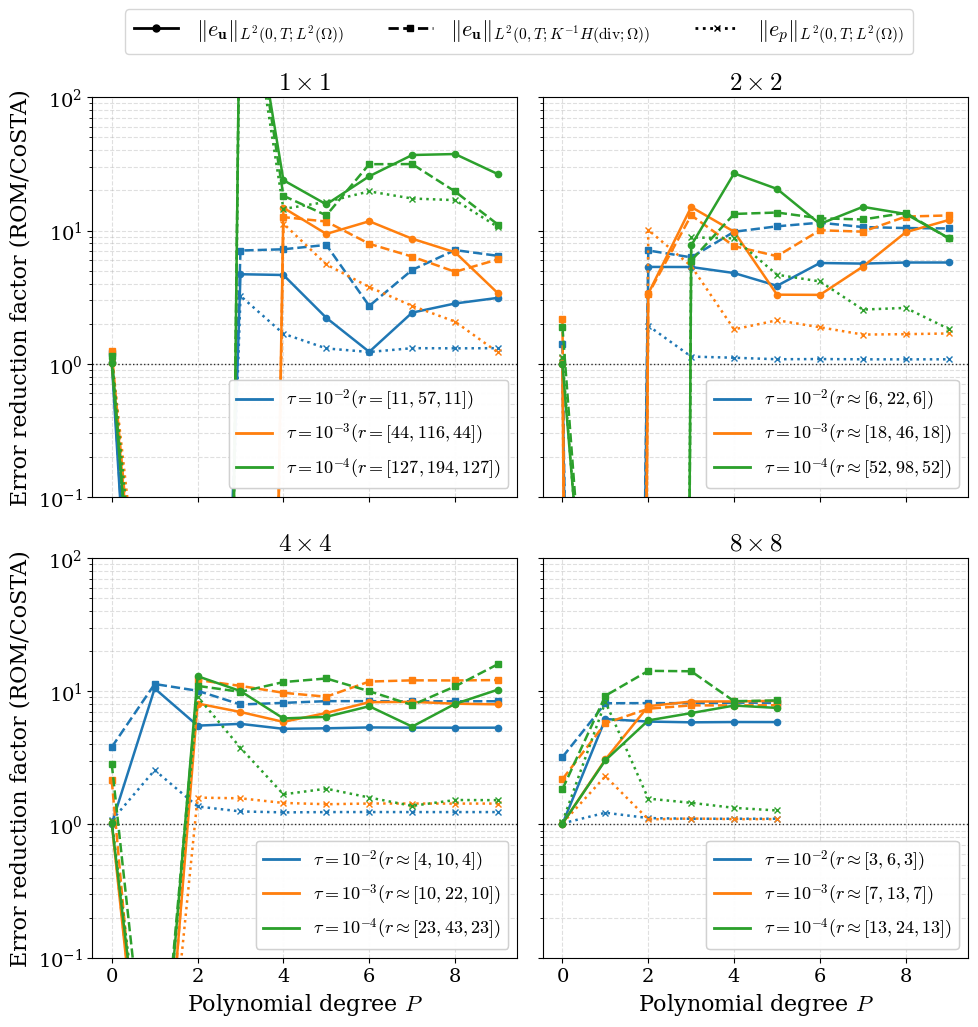

In [5]:

# do all at the same time

def plot_multi_error_improvement_grid(
    runs,
    tau_list,
    metric_triplets,
    ylabel=r"Improvement factor",
    yscale=None,
    panel_width=5.0,
    panel_height=5.2,
    savepath=None,
    clamp_min=0.1,
    clamp_max=100.0,
):
    nplots = len(runs)
    if nplots == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, nplots)
        nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax in axes[nplots:]:
        ax.set_visible(False)

    tau_color_map = {tau: f"C{i}" for i, tau in enumerate(tau_list)}

    style_map = {
        "u_l2": ("-", "o"),
        "u_khdiv": ("--", "s"),
        "p_l2": (":", "x"),
    }

    for idx, (ax, run) in enumerate(zip(axes, runs)):
        results = run["results"]

        ax.set_title(run["name"])
        ax.grid(True, which="both", ls="--", alpha=0.4)
        ax.axhline(1.0, color="black", lw=1.0, ls=":", alpha=0.8)

        # if yscale:
        #     ax.set_yscale(yscale)
        # else:
        #     ax.set_ylim(clamp_min, clamp_max)
        ax.set_yscale(yscale)
        ax.set_ylim(clamp_min, clamp_max)
        row = idx // ncols
        col = idx % ncols
        if row == nrows - 1:
            ax.set_xlabel(r"Polynomial degree $P$")
        if col == 0:
            ax.set_ylabel(ylabel)

        for tau in tau_list:
            tau_key = str(tau)
            if tau_key not in results:
                continue

            block = results[tau_key]
            Pvals_raw = np.asarray(block.get("P", []), dtype=int)
            if Pvals_raw.size == 0:
                continue

            for metric_name, baseline_key, costa_key in metric_triplets:
                baseline_err = np.asarray(block.get(baseline_key, []), dtype=float)
                costa_err = np.asarray(block.get(costa_key, []), dtype=float)

                if baseline_err.size == 0 or costa_err.size == 0:
                    continue

                m = min(Pvals_raw.size, baseline_err.size, costa_err.size)
                Pvals = Pvals_raw[:m]
                baseline_err = baseline_err[:m]
                costa_err = costa_err[:m]

                ratio = np.full(m, np.nan, dtype=float)
                mask = np.isfinite(baseline_err) & np.isfinite(costa_err) & (costa_err != 0.0)
                ratio[mask] = baseline_err[mask] / costa_err[mask]

                Pvals, ratio = filter_valid_P_series(run["payload"], Pvals, ratio)
                finite = np.isfinite(ratio)
                Pvals = Pvals[finite]
                ratio = ratio[finite]
                if Pvals.size == 0:
                    continue

                ls, mk = style_map.get(metric_name, ("-", "o"))
                ax.plot(
                    Pvals,
                    ratio,
                    linestyle=ls,
                    marker=mk,
                    color=tau_color_map[tau],
                    linewidth=1.8,
                    markersize=4.5,
                )

        # Legend 1: tau colors with r-triplet (inside axes)
        r_comp_dict = average_r_components_per_tau(run, tau_list)
        is_single_domain = run["cfg"].get("Nsplit", 1) == 1
        r_symbol = "=" if is_single_domain else r"\approx"
        tau_handles = [
            Line2D([0], [0], color=tau_color_map[tau], lw=2,
                   label=rf"$\tau={format_tau_math(tau)}(r{r_symbol}{format_r_triplet(r_comp_dict[tau])})$")
                #    label=rf"$r{r_symbol}{format_r_triplet(r_comp_dict[tau])}$")
            for i, tau in enumerate(tau_list)
        ]
        leg_tau = ax.legend(handles=tau_handles, loc="lower right", frameon=True, fontsize=13)

        # Legend 2: metric style map (inside axes)
        ax.add_artist(leg_tau)

    metric_handles = [
        Line2D([0], [0], color="black", linestyle=style_map[m][0], marker=style_map[m][1], lw=2, label=lbl)
        for m, lbl in [("u_l2", r"$\|e_{\mathbf{u}}\|_{L^2(0,T;L^2(\Omega))}$"), ("u_khdiv", r"$\|e_{\mathbf{u}}\|_{L^2(0,T;K^{-1}H(\mathrm{div};\Omega))}$"), ("p_l2", r"$\|e_p\|_{L^2(0,T;L^2(\Omega))}$")]
    ]
    fig.legend(
        handles=metric_handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        fontsize=16,
        bbox_to_anchor=(0.53, 1.00),
    )

    fig.tight_layout(rect=(0, 0, 1, 0.95))

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# velocity_metric_triplets = [
#     ("u_l2", "baseline_u_l2_scaled_l2t_mean", "costa_u_l2_scaled_l2t_mean"),
#     ("p_l2", "baseline_p_l2_scaled_l2t_mean", "costa_p_l2_scaled_l2t_mean"),
#     ("u_khdiv", "baseline_u_khdiv_scaled_l2t_mean", "costa_u_khdiv_scaled_l2t_mean"),
# ]
velocity_metric_triplets = [
    ("u_l2", "baseline_u_l2_scaled_l2t_max", "costa_u_l2_scaled_l2t_max"),
    ("p_l2", "baseline_p_l2_scaled_l2t_max", "costa_p_l2_scaled_l2t_max"),
    ("u_khdiv", "baseline_u_khdiv_scaled_l2t_max", "costa_u_khdiv_scaled_l2t_max"),
]

savepath = "figs/baseline_vs_costa_all_velocity_errors_scaled_l2t_mean_transient.pdf"
plot_multi_error_improvement_grid(
    runs=runs,
    tau_list=tau_list,
    metric_triplets=velocity_metric_triplets,
    ylabel=r"Error reduction factor (ROM/CoSTA)",
    yscale="log",
    savepath=savepath,
)


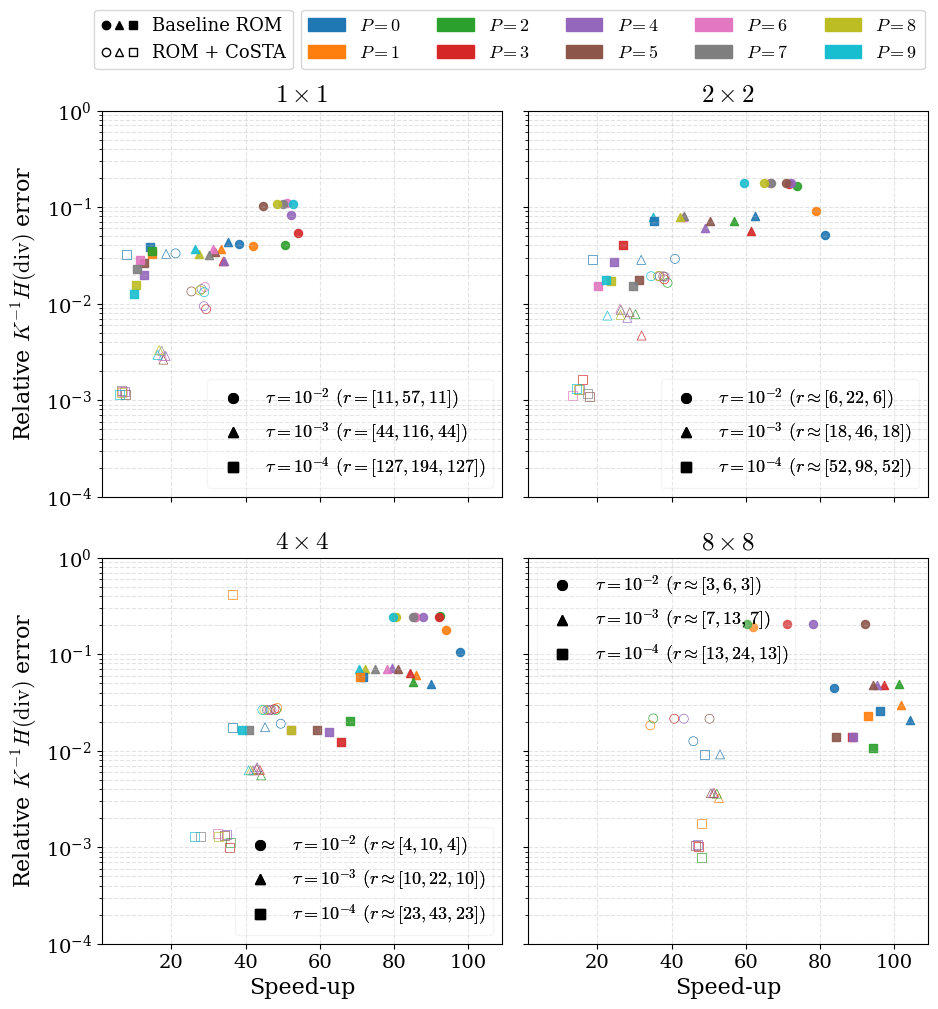

In [6]:

# experiment plot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import Patch


def plot_error_vs_speedup_scatter_grid(
    runs,
    error_key_baseline="baseline_u_khdiv_scaled_l2t_mean",
    error_key_costa="costa_u_khdiv_scaled_l2t_mean",
    speedup_key_baseline="rom_speedup_throughput",
    speedup_key_costa="costa_speedup_throughput",
    yscale="log",
    ymin=1e-5,
    ymax=1.0,
    panel_width=4.8,
    panel_height=5.2,
    savepath=None,
):
    nplots = len(runs)
    if nplots == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, nplots)
        nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax in axes[nplots:]:
        ax.set_visible(False)

    # Global P-color map so colors are consistent across all subplots
    all_P = set()
    for run in runs:
        for tau_key, block in run["results"].items():
            all_P.update(np.asarray(block.get("P", []), dtype=int).tolist())
    P_sorted = sorted(all_P)
    p_color = {p: f"C{i % 10}" for i, p in enumerate(P_sorted)}

    tau_sorted_desc = sorted(tau_list, reverse=True)
    tau_shapes = ["o", "^", "s"]
    tau_shape_names = ["Circle", "Triangle", "Square"]
    tau_marker = {tau: tau_shapes[min(i, len(tau_shapes)-1)] for i, tau in enumerate(tau_sorted_desc)}
    tau_shape_name = {tau: tau_shape_names[min(i, len(tau_shape_names)-1)] for i, tau in enumerate(tau_sorted_desc)}

    for idx, (ax, run) in enumerate(zip(axes, runs)):
        ax.set_title(run["name"])

        row = idx // ncols
        col = idx % ncols
        if row == nrows - 1:
            ax.set_xlabel("Speed-up")
        if col == 0:
            ax.set_ylabel(r"Relative $K^{-1}H(\mathrm{div})$ error")

        for tau in tau_list:
            tau_key = str(tau)
            if tau_key not in run["results"]:
                continue
            block = run["results"][tau_key]

            Pvals = np.asarray(block.get("P", []), dtype=int)
            e_base = np.asarray(block.get(error_key_baseline, []), dtype=float)
            e_costa = np.asarray(block.get(error_key_costa, []), dtype=float)
            s_base = np.asarray(block.get(speedup_key_baseline, []), dtype=float)
            s_costa = np.asarray(block.get(speedup_key_costa, []), dtype=float)

            m = min(Pvals.size, e_base.size, e_costa.size, s_base.size, s_costa.size)
            if m == 0:
                continue

            Pvals = Pvals[:m]
            e_base = e_base[:m]
            e_costa = e_costa[:m]
            s_base = s_base[:m]
            s_costa = s_costa[:m]

            Pvals, e_base, e_costa, s_base, s_costa = filter_valid_P_series(
                run["payload"], Pvals, e_base, e_costa, s_base, s_costa
            )

            good_base = np.isfinite(e_base) & np.isfinite(s_base) & (e_base > 0) & (s_base > 0)
            good_costa = np.isfinite(e_costa) & np.isfinite(s_costa) & (e_costa > 0) & (s_costa > 0)

            for p in np.unique(Pvals[good_base]):
                sel = good_base & (Pvals == p)
                ax.scatter(s_base[sel], e_base[sel], marker=tau_marker[tau], s=34, color=p_color[int(p)], alpha=0.9)

            for p in np.unique(Pvals[good_costa]):
                sel = good_costa & (Pvals == p)
                ax.scatter(
                    s_costa[sel],
                    e_costa[sel],
                    marker=tau_marker[tau],
                    s=42,
                    facecolors="none",
                    edgecolors=p_color[int(p)],
                    linewidths=0.5,
                    alpha=0.95,
                )


        r_comp_dict = average_r_components_per_tau(run, tau_list)
        is_single_domain = run["cfg"].get("Nsplit", 1) == 1
        r_symbol = "=" if is_single_domain else r"\approx"
        tau_handles = [
            Line2D(
                [0], [0],
                marker=tau_marker[tau],
                color="black",
                markerfacecolor="black",
                linestyle="None",
                markersize=7,
                label=rf"$\tau={format_tau_math(tau)}$ $(r{r_symbol}{format_r_triplet(r_comp_dict[tau])})$",
            )
            for tau in tau_sorted_desc
        ]
        leg_tau = ax.legend(handles=tau_handles, loc="best", frameon=True, fontsize=13,framealpha=0.1)
        ax.add_artist(leg_tau)

        ax.set_yscale(yscale)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, which="both", ls="--", alpha=0.35)

    baseline_triplet = (
        Line2D([0], [0], marker="o", color="black", markerfacecolor="black", linestyle="None", markersize=6),
        Line2D([0], [0], marker="^", color="black", markerfacecolor="black", linestyle="None", markersize=6),
        Line2D([0], [0], marker="s", color="black", markerfacecolor="black", linestyle="None", markersize=6),
    )
    costa_triplet = (
        Line2D([0], [0], marker="o", color="black", markerfacecolor="none", linestyle="None", markersize=6),
        Line2D([0], [0], marker="^", color="black", markerfacecolor="none", linestyle="None", markersize=6),
        Line2D([0], [0], marker="s", color="black", markerfacecolor="none", linestyle="None", markersize=6),
    )

    method_handles = [baseline_triplet, costa_triplet]
    method_labels = ["Baseline ROM", "ROM + CoSTA"]

    degree_handles = [
        Patch(facecolor=p_color[p], edgecolor=p_color[p], label=rf"$P={p}$")
        for p in P_sorted
    ]
    fig.legend(
        handles=method_handles,
        labels=method_labels,
        handler_map={tuple: HandlerTuple(ndivide=None, pad=0.2)},
        loc="upper left",
        ncol=1,
        frameon=True,
        fontsize=13,
        bbox_to_anchor=(0.1, 0.98),
    )

    fig.legend(
        handles=degree_handles,
        loc="upper center",
        ncol=5,
        frameon=True,
        fontsize=13,
        bbox_to_anchor=(0.65, 0.98),
    )

    fig.tight_layout(rect=(0, 0, 1, 0.92))

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


plot_error_vs_speedup_scatter_grid(
    runs=runs,
    error_key_baseline="baseline_u_khdiv_scaled_l2t_mean",
    error_key_costa="costa_u_khdiv_scaled_l2t_mean",
    speedup_key_baseline="rom_speedup_throughput",
    speedup_key_costa="costa_speedup_throughput",
    yscale="log",
    ymin=1e-4,
    ymax=1.0,
    savepath="figs/error_vs_speedup_scatter.pdf",
)